In [1]:
import pandas as pd
import geopandas as gpd
import openpyxl
from shapely.geometry import Point
import json
import folium

geral = pd.read_excel('Geral.xlsx', sheet_name='Tabela Geral')
geral['Ano'] = geral['Ano'].astype('Int64')
geral['Processo SEI'] = geral['Processo SEI'].astype('Int64').astype('string')

def formatar_processo_sei(numero):
    if pd.isna(numero):
        return None
    numero = numero.zfill(16)  # Garante 16 dígitos, caso necessário (ajuste conforme o padrão real)
    return f"{numero[:4]}.{numero[4:8]}/{numero[8:15]}-{numero[15:]}"

geral['Processo SEI'] = geral['Processo SEI'].apply(formatar_processo_sei)

geral.rename(columns={'Coordenada X': 'Longitude', 'Coordenada Y': 'Latitude', 'Unidade': 'Secretaria', 'Equipamento 1': 'Tipo Equipamento', 'Equipamento 2': 'Sub Tipo Equipamento'}, inplace=True)
dadosgeo = geral
dadosgeo['Longitude'] = pd.to_numeric(geral['Longitude'], errors='coerce')
dadosgeo['Latitude'] = pd.to_numeric(geral['Latitude'], errors='coerce')
dadosgeo = geral.dropna(subset=['Longitude', 'Latitude'])

geometry = [Point(xy) for xy in zip(dadosgeo["Longitude"], dadosgeo["Latitude"])]
pontos = gpd.GeoDataFrame(dadosgeo, geometry=geometry)
pontos.set_crs(epsg=4326, inplace=True)
print(pontos.crs)

EPSG:4326


In [2]:
print('--------------Filtrando por SEI RESTRITO (266 registros)--------------')
sei_r = geral['Região']=='SEI RESTRITO'
print(sei_r.value_counts())
print('')
print('--------------Mostra número de registros com geolocalização (539) de um total de 1676 registros de empenhos financeiros--------------')
print(len(dadosgeo), len(geral))
print('')
print('--------------Nostra porcentagem de registros com geolocalização (32,16%) de um total de 1676 registros de empenhos financeiros--------------')
print(len(dadosgeo)*100/ len(geral))

--------------Filtrando por SEI RESTRITO (266 registros)--------------
Região
False    1410
True      266
Name: count, dtype: int64

--------------Mostra número de registros com geolocalização (539) de um total de 1676 registros de empenhos financeiros--------------
539 1676

--------------Nostra porcentagem de registros com geolocalização (32,16%) de um total de 1676 registros de empenhos financeiros--------------
32.159904534606206


In [3]:
print('--------------O Trecho Recap tem 504 registros (dos quais 266 são "SEI Restrito". 238 informações relevantes--------------')
geral['Trecho (Recap)'][:].value_counts().sum()

--------------O Trecho Recap tem 504 registros (dos quais 266 são "SEI Restrito". 238 informações relevantes--------------


np.int64(504)

In [4]:
dadosgeo['Trecho (Recap)'].value_counts()[:10]
# 6 desses processos estão no SIMPROC?
# É normal ter trechos repetidos? 

Trecho (Recap)
SIMPROC                                                                         6
Trecho entre Avenida João Batista Conti e Rua São Teodoro                       6
Trecho entre Alça de acesso Ponte Janio Quadros e Marginal Tiete                6
Trecho entre Amador Bueno da Veiga e Viaduto Milton Leão                        5
Trecho entre Rua Cuim e Rua Boipeva                                             5
Trecho Avenda General Penha Brasil                                              4
Trecho entre Rua Barata Ribeiro e Avenida Nove de Julho                         4
Trecho entre Avenida N. Sra. do Ó e Avenida Padre Orlando Garcia da Silveira    4
Trecho entre Rua Camargo, Avenida Caxingui e Avenida Eliseu de Almeida          4
Trecho entre Avenida João Paulo I e Avenida Jose da Natividade Saldanha         4
Name: count, dtype: int64

In [5]:
dadosgeo['Extensão (m)'].value_counts()[:10]
#SIMPROC aqui são 37

Extensão (m)
0          89
SIMPROC    37
2100        3
400         3
300         2
1200        2
1300        2
2160        1
1010        1
1600        1
Name: count, dtype: int64

In [6]:
#Importa a s geometrias das subprefeituras e distritos como geodataframe, mas apenas as colunas necessárias: nome e polígono
subs = gpd.read_file('subprefeituras.geojson', encoding='utf-8')[['nm_subprefeitura','geometry']]
subs = subs.rename(columns={'nm_subprefeitura':'SubPrefeitura'})
distritos = gpd.read_file('EPSG4326-DistritosSP.geojson', encoding='utf-8')[['nm_distrito_municipal', 'geometry']]
distritos = distritos.rename(columns={'nm_distrito_municipal':'Distrito'})

In [7]:
print(f"{len(distritos['Distrito'].unique())} distritos")
print(f"{len(subs['SubPrefeitura'].unique())} subprefeituras")


96 distritos
32 subprefeituras


In [8]:
print('--------------Distritos carregados--------------')
print(distritos['Distrito'].unique())
print('\n--------------Subprefeituras carregadas--------------')
print(subs['SubPrefeitura'].unique())

--------------Distritos carregados--------------
['MANDAQUI' 'MARSILAC' 'MOEMA' 'MOOCA' 'MORUMBI' 'PARI' 'PARQUE DO CARMO'
 'PEDREIRA' 'PENHA' 'PERDIZES' 'PERUS' 'PINHEIROS' 'PIRITUBA' 'PONTE RASA'
 'RAPOSO TAVARES' 'REPUBLICA' 'RIO PEQUENO' 'SACOMA' 'SANTA CECILIA'
 'SANTANA' 'SANTO AMARO' 'SAO DOMINGOS' 'SAO LUCAS' 'SAO MATEUS'
 'SAO MIGUEL' 'SAO RAFAEL' 'SAPOPEMBA' 'SAUDE' 'SE' 'SOCORRO' 'TATUAPE'
 'TREMEMBE' 'TUCURUVI' 'VILA ANDRADE' 'VILA CURUCA' 'VILA FORMOSA'
 'VILA GUILHERME' 'VILA JACUI' 'VILA LEOPOLDINA' 'VILA MARIA'
 'VILA MARIANA' 'VILA MATILDE' 'VILA MEDEIROS' 'VILA PRUDENTE'
 'JARDIM ANGELA' 'PARELHEIROS' 'VILA SONIA' 'AGUA RASA'
 'ALTO DE PINHEIROS' 'ANHANGUERA' 'ARICANDUVA' 'ARTUR ALVIM' 'BARRA FUNDA'
 'BELA VISTA' 'BELEM' 'BOM RETIRO' 'BRAS' 'BRASILANDIA' 'BUTANTA'
 'CACHOEIRINHA' 'CAMBUCI' 'CAMPO BELO' 'CAMPO GRANDE' 'CAMPO LIMPO'
 'CANGAIBA' 'CAPAO REDONDO' 'CARRAO' 'CASA VERDE' 'CIDADE ADEMAR'
 'CIDADE DUTRA' 'CIDADE LIDER' 'CIDADE TIRADENTES' 'CONSOLACAO' 'CURSINO'

In [9]:
ipvs = gpd.read_file('IPVS.geojson', encoding='utf-8')[['cd_indice_vulnerabilidade_social', 'geometry']]
ipvs.rename(columns={'cd_indice_vulnerabilidade_social': 'IPVS'}, inplace=True)
mapeamento = {
    0.0: 'Sem Classificação',
    1.0: '1- Baixíssima vulnerabilidade',
    2.0: '2- Vulnerabilidade muito baixa',
    3.0: '3- Vulnerabilidade baixa',
    4.0: '4- Vulnerabilidade média',
    5.0: '5- Vulnerabilidade alta (urbanos)',
    6.0: '6- Vulnerabilidade muito alta (aglomerados subnormais urbanos)',
    7.0: '7- Vulnerabilidade alta (rurais)'
}

ipvs['Vulnerabilidade'] = ipvs['IPVS'].map(mapeamento)

In [10]:
ipvs

,IPVS,geometry,Vulnerabilidade
0,NaN,"POLYGON ((-46.82432 -23.40665, -46.82426 -23.4...",NaN
1,NaN,"POLYGON ((-46.82432 -23.40665, -46.8239 -23.40...",NaN
2,NaN,"POLYGON ((-46.8243 -23.40327, -46.82407 -23.40...",NaN
3,0.0,"POLYGON ((-46.81948 -23.40017, -46.81935 -23.4...",Sem Classificação
4,NaN,"POLYGON ((-46.78263 -23.40341, -46.78264 -23.4...",NaN
...,...,...,...
18970,2.0,"POLYGON ((-46.54973 -23.60329, -46.54985 -23.6...",2- Vulnerabilidade muito baixa
18971,2.0,"POLYGON ((-46.54865 -23.6014, -46.54843 -23.60...",2- Vulnerabilidade muito baixa
18972,3.0,"POLYGON ((-46.54779 -23.60172, -46.54765 -23.6...",3- Vulnerabilidade baixa
18973,2.0,"POLYGON ((-46.50608 -23.52334, -46.50593 -23.5...",2- Vulnerabilidade muito baixa


In [11]:
pontos = gpd.sjoin(pontos, subs, how="inner")
pontos = pontos.drop(['index_right'], axis=1)
pontos = gpd.sjoin(pontos, distritos, how="inner")
pontos = pontos.drop(['index_right'], axis=1)
pontos = gpd.sjoin(pontos, ipvs, how="inner")
pontos = pontos.drop(['index_right'], axis=1)
pontos.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 537 entries, 0 to 1485
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   Ano                      535 non-null    Int64   
 1   Nota Empenho             535 non-null    object  
 2   Nota Reserva             535 non-null    object  
 3   Ata CMDP                 313 non-null    object  
 4   Processo SEI             535 non-null    object  
 5   Secretaria               535 non-null    object  
 6   Função                   535 non-null    object  
 7   Sub Função               535 non-null    object  
 8   Programa                 535 non-null    object  
 9   Atividade                535 non-null    object  
 10  Sub Elemento Despesa     535 non-null    object  
 11  Item Despesa             535 non-null    object  
 12  Observação Empenho       535 non-null    object  
 13  Contrato                 533 non-null    object  
 14  Credor

In [12]:
pontos['Vulnerabilidade'].value_counts()

Vulnerabilidade
2- Vulnerabilidade muito baixa                                    281
3- Vulnerabilidade baixa                                           87
1- Baixíssima vulnerabilidade                                      62
4- Vulnerabilidade média                                           42
5- Vulnerabilidade alta (urbanos)                                  25
Sem Classificação                                                  19
6- Vulnerabilidade muito alta (aglomerados subnormais urbanos)     16
Name: count, dtype: int64

In [13]:
pontos['Vulnerabilidade'].value_counts(normalize=True)

Vulnerabilidade
2- Vulnerabilidade muito baixa                                    0.528195
3- Vulnerabilidade baixa                                          0.163534
1- Baixíssima vulnerabilidade                                     0.116541
4- Vulnerabilidade média                                          0.078947
5- Vulnerabilidade alta (urbanos)                                 0.046992
Sem Classificação                                                 0.035714
6- Vulnerabilidade muito alta (aglomerados subnormais urbanos)    0.030075
Name: proportion, dtype: float64

In [14]:
#16 pontos de mais alta vulnerabilidade
ddp = pontos[pontos['IPVS'] == 6.0]
ddp

,Ano,Nota Empenho,Nota Reserva,Ata CMDP,Processo SEI,Secretaria,Função,Sub Função,Programa,Atividade,...,Região,Extensão (m),Trecho (Recap),Latitude,Longitude,geometry,SubPrefeitura,Distrito,IPVS,Vulnerabilidade
92,2020,61425/2020,36933/2020,30/06/2020,6012.2020/0019352-7,SMSUB,15 - URBANISMO,452 - SERVIÇOS URBANOS,3006 - DIREITOS DA PESSOA COM DEFICIÊNCIA,1169 - REFORMA E ACESSIBILIDADE EM PASSEIOS PÚ...,...,Sul,NaN,Trecho entre Rua Jacaraipe e Praça Orlandia,-23.592955,-46.584612,POINT (-46.58461 -23.59295),VILA PRUDENTE,VILA PRUDENTE,6.0,6- Vulnerabilidade muito alta (aglomerados sub...
598,2022,87172/2022,45513/2022,2022-08-08 00:00:00,7610.2022/0001325-9,COHAB,16 - HABITAÇÃO,451 - INFRA-ESTRUTURA URBANA,3002 - ACESSO À MORADIA ADEQUADA,3356 - REGULARIZAÇÃO FUNDIÁRIA,...,Sul,NaN,NaN,-23.706569,-46.687452,POINT (-46.68745 -23.70657),CAPELA DO SOCORRO,CIDADE DUTRA,6.0,6- Vulnerabilidade muito alta (aglomerados sub...
676,2023,115806/2023,45356/2023,2023-06-13 00:00:00,6012.2023/0013522-0,SMSUB,15 - URBANISMO,451 - INFRA-ESTRUTURA URBANA,3022 - REQUALIFICAÇÃO E PROMOÇÃO DA OCUPAÇÃO D...,"1170 - INTERVENÇÃO, URBANIZAÇÃO E MELHORIA DE ...",...,Norte,NaN,NaN,-23.454656,-46.575718,POINT (-46.57572 -23.45466),JACANA-TREMEMBE,JACANA,6.0,6- Vulnerabilidade muito alta (aglomerados sub...
749,2023,121700/2023,82639/2023,NaN,6018.2023/0106445-1,SMS,10 - SAÚDE,301 - ATENÇÃO BÁSICA,3003 - AÇÕES E SERVIÇOS DA SAÚDE EM ATENÇÃO BÁ...,"5204 - AVANÇA SAÚDE SP - AMPLIAÇÃO, REFORMA E ...",...,Norte,NaN,NaN,-23.673686,-46.666510,POINT (-46.66651 -23.67369),CIDADE ADEMAR,CIDADE ADEMAR,6.0,6- Vulnerabilidade muito alta (aglomerados sub...
757,2023,122819/2023,85832/2023,NaN,6018.2023/0110039-3,SMS,10 - SAÚDE,301 - ATENÇÃO BÁSICA,3003 - AÇÕES E SERVIÇOS DA SAÚDE EM ATENÇÃO BÁ...,"5204 - AVANÇA SAÚDE SP - AMPLIAÇÃO, REFORMA E ...",...,Leste,NaN,NaN,-23.685602,-46.783781,POINT (-46.78378 -23.6856),CAMPO LIMPO,CAPAO REDONDO,6.0,6- Vulnerabilidade muito alta (aglomerados sub...
808,2023,134659/2023,76583/2023,NaN,0000.2014/0337134-9,SMS,10 - SAÚDE,301 - ATENÇÃO BÁSICA,3003 - AÇÕES E SERVIÇOS DA SAÚDE EM ATENÇÃO BÁ...,"5204 - AVANÇA SAÚDE SP - AMPLIAÇÃO, REFORMA E ...",...,Leste,SIMPROC,NaN,-23.630344,-46.443622,POINT (-46.44362 -23.63034),SAO MATEUS,SAO RAFAEL,6.0,6- Vulnerabilidade muito alta (aglomerados sub...
989,2023,76160/2023,35347/2023,NaN,6018.2023/0074602-8,SMS,10 - SAÚDE,301 - ATENÇÃO BÁSICA,3003 - AÇÕES E SERVIÇOS DA SAÚDE EM ATENÇÃO BÁ...,"5204 - AVANÇA SAÚDE SP - AMPLIAÇÃO, REFORMA E ...",...,NaN,NaN,NaN,-23.479579,-46.414475,POINT (-46.41448 -23.47958),SAO MIGUEL,JARDIM HELENA,6.0,6- Vulnerabilidade muito alta (aglomerados sub...
990,2023,76181/2023,39337/2023,NaN,6018.2023/0074740-7,SMS,10 - SAÚDE,301 - ATENÇÃO BÁSICA,3003 - AÇÕES E SERVIÇOS DA SAÚDE EM ATENÇÃO BÁ...,"5204 - AVANÇA SAÚDE SP - AMPLIAÇÃO, REFORMA E ...",...,Oeste,NaN,NaN,-23.608871,-46.701682,POINT (-46.70168 -23.60887),BUTANTA,MORUMBI,6.0,6- Vulnerabilidade muito alta (aglomerados sub...
997,2023,81487/2023,39336/2023,NaN,6018.2023/0074704-0,SMS,10 - SAÚDE,301 - ATENÇÃO BÁSICA,3003 - AÇÕES E SERVIÇOS DA SAÚDE EM ATENÇÃO BÁ...,"5204 - AVANÇA SAÚDE SP - AMPLIAÇÃO, REFORMA E ...",...,Leste,NaN,NaN,-23.487469,-46.449037,POINT (-46.44904 -23.48747),SAO MIGUEL,SAO MIGUEL,6.0,6- Vulnerabilidade muito alta (aglomerados sub...
1010,2023,82432/2023,45368/2023,2025-06-13 00:00:00,6012.2023/0014493-9,SMSUB,15 - URBANISMO,452 - SERVIÇOS URBANOS,3022 - REQUALIFICAÇÃO E PROMOÇÃO DA OCUPAÇÃO D...,"1170 - INTERVENÇÃO, URBANIZAÇÃO E MELHORIA DE ...",...,Sul,NaN,NaN,-23.644960,-46.751793,POINT (-46.75179 -23.64496),CAMPO LIMPO,CAMPO LIMPO,6.0,6- Vulnerabilidade muito alta (aglomerados sub...


In [15]:
# Mapa Subprefeituras SP
# subs.explore(
#     color='black',
#     # tiles='CartoDB positron',
#     zoom_control=True,
#     zoom_start=11,
#     # = subs['SubPrefeitura'],
#     highlight_kwds={
#         'fillOpacity': 0
#         },
#     style_kwds={'weight': 1,
#                 'color': 'black',
#                 'fillColor': 'lightblue',
#                 'fillOpacity': 0.2
#                 }
# )

In [16]:
# Mapa distritos SP
# distritos.explore(
#     color='black',
#     tiles='CartoDB positron',
#     zoom_control=True,
#     zoom_start=11,
#     # = subs['SubPrefeitura'],
#     highlight_kwds={
#         'fillOpacity': 0
#         },
#     style_kwds={'weight': 1,
#                 'color': 'black',
#                 'fillColor': 'lightgreen',
#                 'fillOpacity': 0.2}
# )

In [18]:
#Mapa pontos vermelhos
pontos.explore(
    color='black',
    tiles='CartoDB positron',
    zoom_control=True,
    zoom_start=11,
    marker_kwds={
        'radius': 10,
        'fillColor': 'red',
        'color': 'black',
        'fillOpacity': 0.8,
        'weight': 1,
        'opacity': 0.8,
        'popup': folium.GeoJsonPopup(
            fields=['Ano', 'Processo SEI', 'Secretaria', 'Tipo Equipamento', 'Sub Tipo Equipamento', 'Trecho (Recap)', 'Valor Empenho'],
            aliases=['Ano', 'Processo SEI', 'Secretaria', 'Tipo Equipamento', 'Sub Tipo Equipamento', 'Trecho (Recap)', 'Valor Empenho'],
            localize=True,
            labels=True
        )
    },
    highlight_kwds={
        'fillOpacity': 0
        },
    style_kwds={'weight': 1,
                'color': 'black',
                'fillColor': 'red',
                'fillOpacity': 0.8}
)

<Axes: title={'center': 'Valores empenhados por Ano'}, xlabel='Ano'>

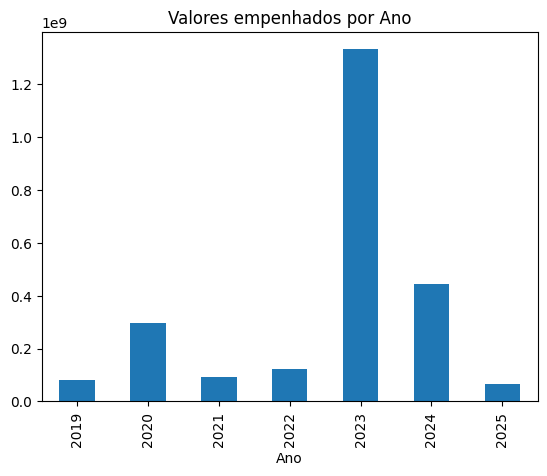

In [ ]:
geral['Valor Empenho'].groupby(geral['Ano']).sum().plot(kind='bar', title='Valores empenhados por Ano')

<Axes: title={'center': 'Valores empenhados por Ano'}, xlabel='Ano'>

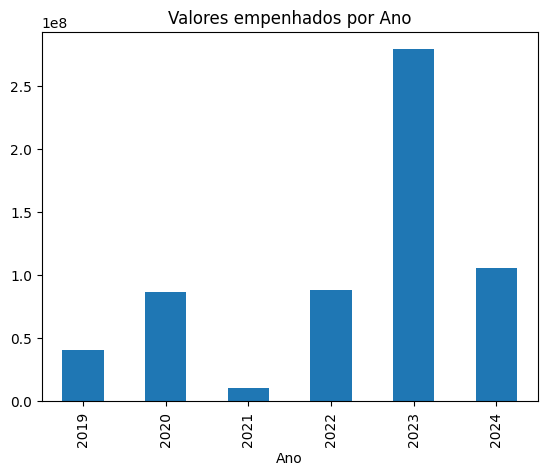

In [ ]:
pontos['Valor Empenho'].groupby(pontos['Ano']).sum().plot(kind='bar', title='Valores empenhados por Ano')